Korzystanie z narzędzi generatywnej AI w rozwiązywaniu zadań nie jest dozwolone

<img src="no_AI.png" alt="Use of AI allowed only when properly documented " width="100" height="100">

---
# Klasteryzacja
---

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
import networkx as nx
import seaborn as sns

from pathlib import Path
from scipy.spatial.distance import pdist, squareform
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm
from sklearn.cluster import KMeans

In [4]:
main_path = Path(".")
coord_dir = main_path / "coords"

Zajmiemy się analizą klastrów powstałych na podstawie cech struktur białkowych. Ładujemy współrzędne przestrzenne 6,631 białek ze zbioru [CATH](https://www.cathdb.info/browse/tree). Następnie:
- generujemy macierze odległości aminokwasów dla każdego białka
- transformujemy macierz odległości do macierzy podobieństwa (naturalna normalizacja między 0 a 1)
- tworzmy graf na podstawie macierzy podobieństwa
- konstruujemy wektor cech na podstawie podstawowych statystyk w grafie
- wybieramy dwie przykładowe cechy i sprawdzamy, czy rozróżniają one nasze białka

# Macierz cech dla jednego białka

## Macierz odległości

In [5]:
for file_path in sorted(coord_dir.glob("*.csv")):
    df = pd.read_csv(file_path)
    coords = df[['x', 'y', 'z']].values
    dist_mat = squareform(pdist(coords, metric='euclidean'))
    print(file_path.stem)
    break

16pkA01


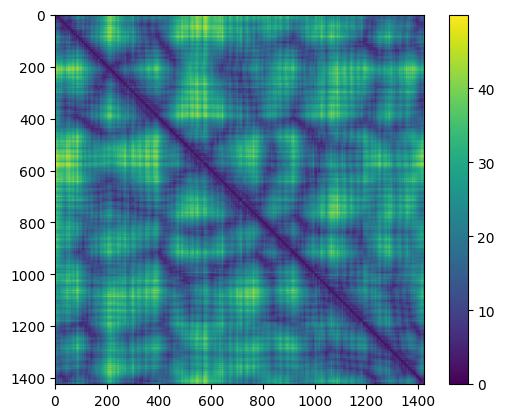

In [6]:
plt.imshow(dist_mat)
plt.colorbar();

## Macierz podobieństwa

In [7]:
def make_sim_matrix(dist_matrix, sigma=10):
    # Transformacja jądrem Gaussowskim
    sim_matrix = np.exp(-np.square(dist_matrix) / (2 * sigma**2))
    # Obsługa niestandardowych wartości 
    sim_matrix[np.isinf(dist_matrix)] = 0
    sim_matrix[np.isnan(dist_matrix)] = 0
    return sim_matrix

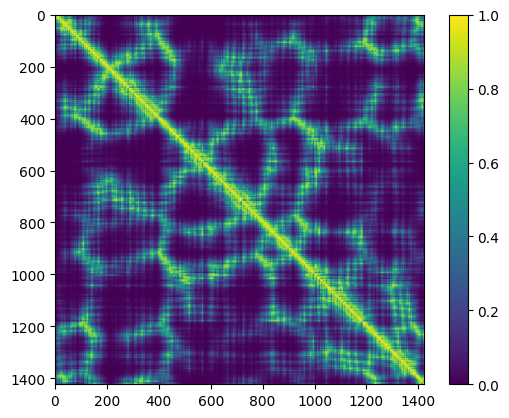

In [8]:
sim_mat = make_sim_matrix(dist_mat)
plt.imshow(sim_mat, vmin=0, vmax=1)
plt.colorbar();

## Macierze cech

In [9]:
def sim_to_graph(sim_matrix, threshold=0.1):
    """
    Konwertuje macierz podobieństwa na nieskierowany graf ważony (NetworkX).
    Krawędzie są dodawane tylko wtedy, gdy wartość podobieństwa przekracza określony próg.
    
    Parametry:
    -----------
    sim_matrix : np.ndarray
        Kwadratowa macierz podobieństwa (2D), symetryczna, z wartościami w przedziale [0, 1].
    
    threshold : float, domyślnie 0.01
        Próg minimalnej wartości podobieństwa, aby utworzyć krawędź pomiędzy dwoma wierzchołkami.
        Mniejsze wartości są ignorowane jako szum.
    
    Zwraca:
    --------
    G : networkx.Graph
        Graf nieskierowany z wagami odpowiadającymi wartościom podobieństwa.
    """
    n = sim_matrix.shape[0]
    G = nx.Graph()
    G.add_nodes_from(range(n))

    rows, cols = np.where(np.triu(sim_matrix, k=1) > threshold)
    weights = sim_matrix[rows, cols]
    edges = zip(rows, cols, weights)
    G.add_weighted_edges_from(edges)
    
    return G


def graph_features(G):
    """
    Oblicza zestaw podstawowycj cech grafu na podstawie macierzy podobieństwa 
    przekształconej do grafu NetworkX.

    Parametry:
    -----------
    G : networkx.Graph
        Graf nieskierowany z wagami na krawędziach (podobieństwa).

    Zwraca:
    --------
    np.ndarray
        Wektor cech w postaci:
        [liczba_wierzchołków, liczba_krawędzi, średni_stopień, wariancja_stopnia,
         średni_ważony_stopień, gęstość_grafu, średni_stopień_sąsiadów]
    """
    n = G.number_of_nodes()
    m = G.number_of_edges()

    degrees = np.array([d for _, d in G.degree()])
    weighted_degrees = np.array([d for _, d in G.degree(weight='weight')])
    
    neighbor_degrees = list(nx.average_neighbor_degree(G).values())
    avg_neighbor_deg = np.mean(neighbor_degrees) if neighbor_degrees else 0

    return np.array([
        n,
        m,
        degrees.mean() if n > 0 else 0,
        degrees.var() if n > 0 else 0,
        weighted_degrees.mean() if n > 0 else 0,
        nx.density(G) if n > 1 else 0,
        avg_neighbor_deg,
    ])

In [10]:
G = sim_to_graph(sim_mat, threshold=0.8)

In [11]:
features = graph_features(G)
features

array([1.42400000e+03, 3.53810000e+04, 4.96924157e+01, 2.12760729e+02,
       4.38002763e+01, 3.49208825e-02, 5.19555112e+01])

# Macierz cech dla zbioru białek

Konstruujemy wektory cech dla wszystkich białek:

In [12]:
COMPUTE_FEATURES = False  # liczymy (~20 min) czy ładujemy z pliku?

In [13]:
if COMPUTE_FEATURES:
    feature_vectors = {}
    for file_path in tqdm(sorted(coord_dir.glob("*.csv"))):
        df = pd.read_csv(file_path)
        coords = df[['x', 'y', 'z']].values
        dist_mat = squareform(pdist(coords, metric='euclidean'))
        sim_mat = make_sim_matrix(dist_mat)
        G = sim_to_graph(sim_mat, threshold=0.5)
        features = graph_features(G)
        feature_vectors[file_path.stem] = features
        np.savez(main_path / 'features.npz', **feature_vectors)
else:
    feature_vectors = np.load(main_path / 'features.npz')
    feature_vectors = {key: feature_vectors[key] for key in feature_vectors.files}

### Ramka danych

In [14]:
columns = [
    "num_nodes",             # liczba wierzchołków
    "num_edges",             # liczba krawędzi
    "mean_degree",           # średni stopień
    "var_degree",            # warinacja stopnia
    "mean_weighted_degree",  # średni ważony stopień
    "density",               # gęstość grafu
    "avg_neighbor_degree"    # średni stopień sąsiadów
]

data = pd.DataFrame.from_dict(feature_vectors, orient='index', columns=columns)

## Korelacja między cechami

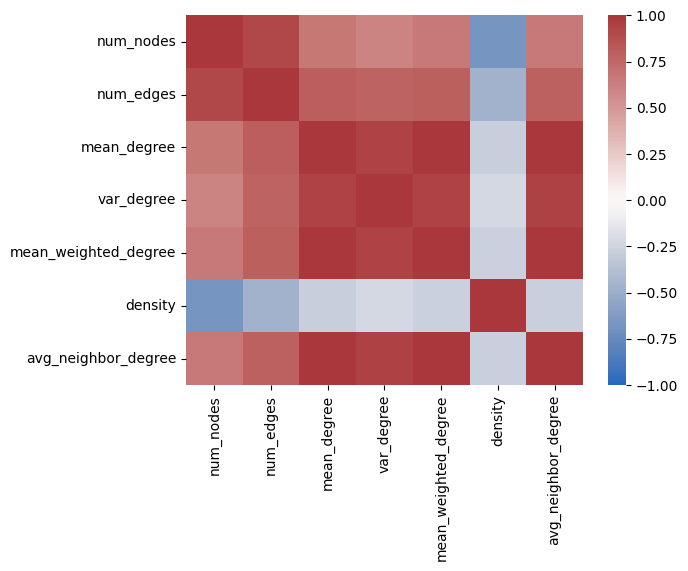

In [15]:
sns.heatmap(data.corr(), vmin=-1, vmax=1, cmap='vlag');

## Wykres

Wybierzmy dwie nieskorelowane cechy i sprawdźmy, czy formują się jakieś potencjalne klastry:

In [16]:
feature1 = 'density'
feature2 = 'mean_weighted_degree'

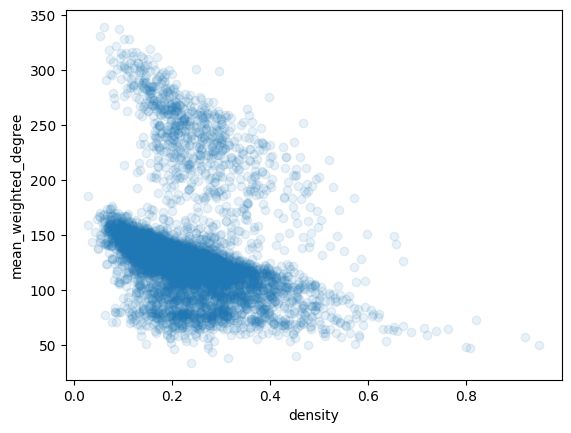

In [17]:
plt.scatter(data[feature1], data[feature2], alpha=0.1)
plt.xlabel(feature1)
plt.ylabel(feature2);

## Metadane (typ białka)

In [19]:
metadata = pd.read_csv(Path('metadata.txt'), delimiter='\t', 
                       header=None, names=['protein', 'C', 'A', 'T', 'H'], index_col='protein')

In [20]:
data = data.join(metadata)

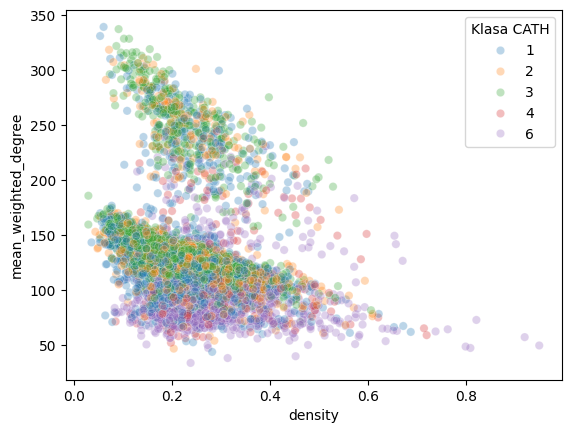

In [21]:
sns.scatterplot(data=data, x=feature1, y=feature2, hue='C', palette='tab10', alpha=0.3)
plt.xlabel(feature1)
plt.ylabel(feature2)
plt.legend(title='Klasa CATH')
plt.show()

Jak widać, skonstruowane przez nas cechy są zbyt proste, żeby oznaczały klasę białka. Można jednak generować cechy inaczej np. za pomocą grafletów lub prostych sieci działających na macierzach dystansów / podobieństwa np. CNN lub GNN.

# Klastrowanie

## Skalowanie cech

Dla wielu algorytmów, zwłaszcza tych opartych na odległości, skalowanie cech jest kluczowe:

In [22]:
X = data[[feature1, feature2]].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X.values)

Użyjmy klasycznego algorytmu `k-means`:

In [23]:
k = 2
kmeans = KMeans(n_clusters=k, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

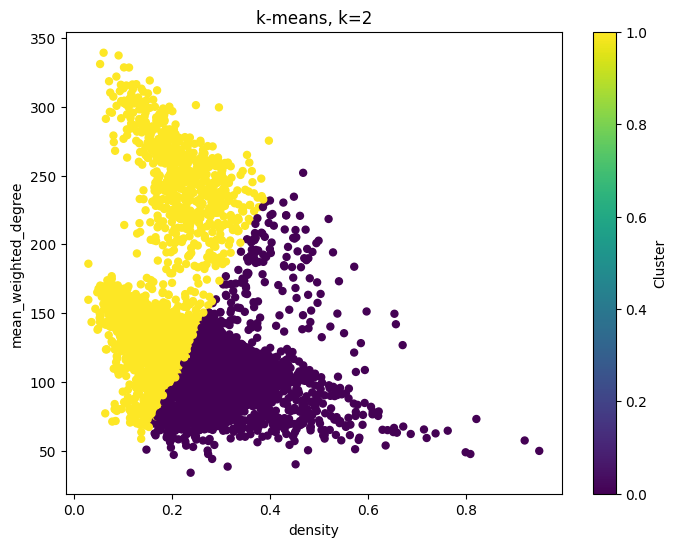

In [24]:
X.loc[:, f'k-mean_{k}'] = clusters
plt.figure(figsize=(8,6))
plt.scatter(X['density'], X['mean_weighted_degree'], c=X[f'k-mean_{k}'], cmap='viridis', s=25)
plt.xlabel(feature1)
plt.ylabel(feature2)
plt.title(f'k-means, k={k}')
plt.colorbar(label='Cluster')
plt.show()

Nie wygląda to dobrze...